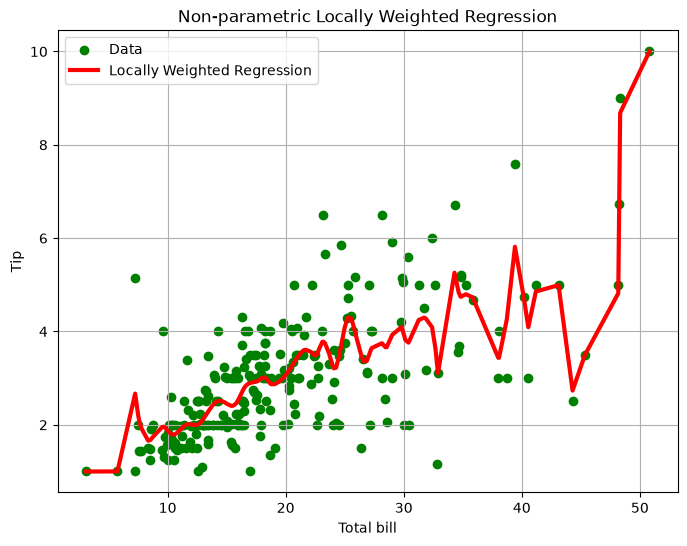

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
data = sns.load_dataset("tips")
bill = data["total_bill"].values
tip = data["tip"].values
def local_regression(X, y, tau):
    m = len(X)
    y_pred = np.zeros(m)
    for i in range(m):
        weights = np.exp(-np.sum((X - X[i])**2, axis=1) / (2 * tau**2))
        W = np.diag(weights)
        try:
            theta = np.linalg.solve(X.T @ W @ X, X.T @ W @ y)
        except np.linalg.LinAlgError:
            theta = np.linalg.pinv(X.T @ W @ X) @ X.T @ W @ y
        y_pred[i] = X[i] @ theta
    return y_pred
X = np.column_stack((np.ones(len(bill)), bill))
y = tip
tau = 0.5
y_pred = local_regression(X, y, tau)
sort_idx = np.argsort(bill)
xsort = bill[sort_idx]
ysort = y_pred[sort_idx]
plt.figure(figsize=(8, 6))
plt.scatter(bill, tip, color="green", label="Data")
plt.plot(xsort, ysort, color="red", linewidth=3,
         label="Locally Weighted Regression")
plt.xlabel("Total bill")
plt.ylabel("Tip")
plt.title("Non-parametric Locally Weighted Regression")
plt.legend()
plt.grid(True)
plt.show()
